# Baseline v0: Raw features + LightGBM (no feature engineering) 

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Imports & Path Setup:
sys.path.append("../src")   # shared: config, data_loader, feature_init_utils, project_utils
sys.path.append("../v0")    # version modules: preproc_v0, split_v0, train_v0, evaluate_v0

# Load processed data (merged + memory reduced + initial features)
from data_loader import load_processed
from config import PROJECT_ROOT

# Step 1: Load Preprocessed Data

In [2]:
train, test = load_processed(PROJECT_ROOT / "data")

>> Loading processed parquet files...
   Train: 590,540 rows × 439 cols (1565 MB)
   Test:  506,691 rows × 438 cols (1357 MB)
   Dtypes: {dtype('float32'): np.int64(399), dtype('O'): np.int64(32), dtype('int32'): np.int64(4), dtype('int64'): np.int64(2), dtype('int8'): np.int64(1), dtype('int16'): np.int64(1)}

   Train preview (top 7 rows):


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_36,id_37,id_38,DeviceType,DeviceInfo,tx_day,tx_dow,tx_hour,tx_dom,DeviceType_filled
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,None,None,None,None,None,1,1,0,2,No device info
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,None,None,None,None,None,1,1,0,2,No device info
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,None,None,None,None,None,1,1,0,2,No device info
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,None,None,None,None,None,1,1,0,2,No device info
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,1,1,0,2,mobile
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,None,None,None,None,None,1,1,0,2,No device info
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,None,None,None,None,None,1,1,0,2,No device info


# Step 2: Separate Target Variable (before preprocessing)

In [3]:
# === Separate target (y) from train before preprocessing ===
from config import TARGET, NON_FEATURE_COLS

y = train[TARGET].copy()

print(f"Target: {TARGET}")
print(f"Target shape: {y.shape}")
print(f"Fraud rate: {y.mean():.4f} ({y.mean():.2%})")

Target: isFraud
Target shape: (590540,)
Fraud rate: 0.0350 (3.50%)


# Step 3: Time-Based Train / Validation Split

In [4]:
from split_v0 import time_split
from config import TIME_COL, TRAIN_RATIO

X_train, X_val, y_train, y_val = time_split(
    train, y, time_col=TIME_COL, train_ratio=TRAIN_RATIO
)

>> Time-based split...
   Total samples: 590,540
   Train ratio: 80%

   Time boundary: 12,192,854
   Train period: 86,400 — 12,192,842
   Val period:   12,192,900 — 15,811,131

   Train size: 472,432 (80.0%)
   Val size:   118,108 (20.0%)

   Fraud rate — train: 0.0351 (3.51%)
   Fraud rate — val:   0.0344 (3.44%)


# Step 4: Preprocess — Fit on Train, Transform on Validation 
* **no data leakage**

In [5]:
from preproc_v0 import preprocess_fit, preprocess_transform
from config import NON_FEATURE_COLS

# Fit on train — learn encoding mappings
X_train, encoding_map = preprocess_fit(X_train, cols_to_drop=NON_FEATURE_COLS)

# Transform val — apply same mappings (no data leakage)
X_val = preprocess_transform(X_val, encoding_map, cols_to_drop=NON_FEATURE_COLS)

PREPROCESSING v0 — FIT (train)
>> Encoding categorical columns (fit on train)...
   Shape before: (472432, 439)
   Found 32 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5']...
   Encoded 32 columns
   Shape after: (472432, 439)

>> Filling missing values with -1...
   NaN before: 83,270,573 values in 384 columns
   NaN after:  0

>> Dropping non-feature columns...
   Shape before: (472432, 439)
   Dropped: ['isFraud', 'TransactionID', 'TransactionDT']
   Shape after: (472432, 436)

   Final shape: (472432, 436)
   Dtypes: {dtype('float32'): np.int64(399), dtype('int32'): np.int64(34), dtype('int64'): np.int64(2), dtype('int16'): np.int64(1)}
PREPROCESSING v0 — TRANSFORM (val/test)
>> Encoding categorical columns (transform)...
   Shape before: (118108, 439)
   Transformed 32 columns
   Unseen values (mapped to -2): 8,665
   Shape after: (118108, 439)

>> Filling missing values with -1...
   NaN before: 20,908,321 value

# Step 5: Train LightGBM — Default Parameters, Early Stopping

In [6]:
from train_v0 import train_lgbm

model, y_pred_val = train_lgbm(X_train, y_train, X_val, y_val)

>> Training LightGBM...
   Train: 472,432 samples × 436 features
   Val:   118,108 samples × 436 features
   Early stopping: 200 rounds
   Key params: lr=0.05, leaves=128, estimators=3000
Training until validation scores don't improve for 200 rounds
[100]	valid_0's auc: 0.908372
[200]	valid_0's auc: 0.918172
[300]	valid_0's auc: 0.919063
[400]	valid_0's auc: 0.919364
[500]	valid_0's auc: 0.918737
Early stopping, best iteration is:
[367]	valid_0's auc: 0.919643

   Best iteration: 367
   Best AUC on val: 0.919643


# Step 6: Evaluate V0
 * ROC AUC
 * PR AUC
 * ROC & PR Curves

EVALUATION RESULTS
   ROC AUC:  0.919643
   PR AUC:   0.580424
   Threshold: 0.5

   Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114044
           1       0.83      0.37      0.51      4064

    accuracy                           0.98    118108
   macro avg       0.90      0.68      0.75    118108
weighted avg       0.97      0.98      0.97    118108



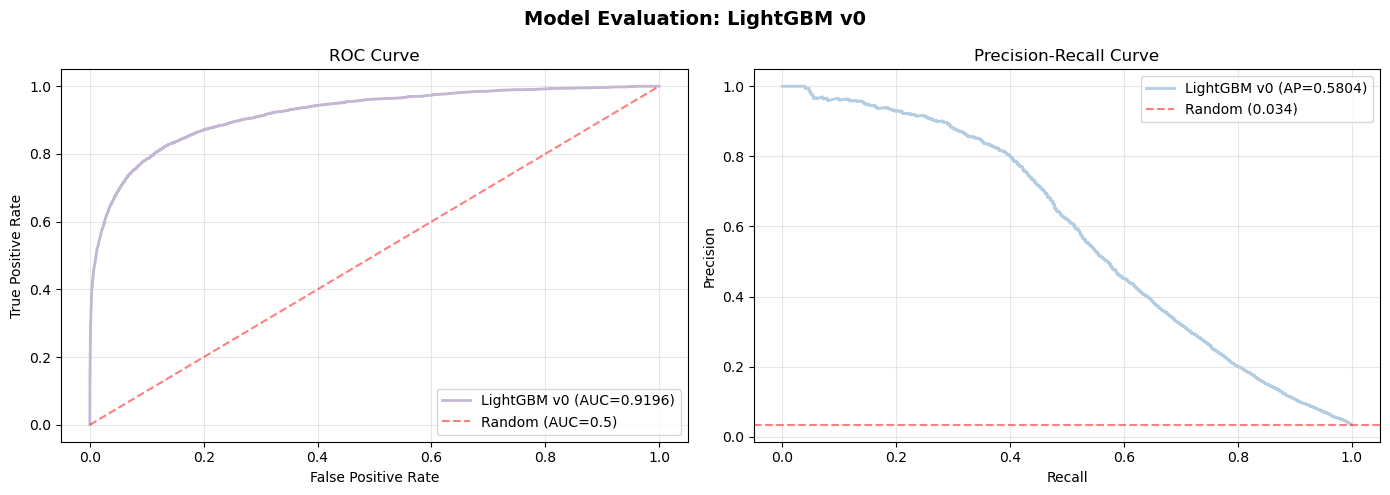

In [7]:
from evaluate_v0 import compute_metrics, plot_roc_pr

metrics = compute_metrics(y_val, y_pred_val)
plot_roc_pr(y_val, y_pred_val)

# Step 7 — Threshold Analysis at Multiple Cutoffs
* Precision
* Recall
* F1 

In [8]:
# === Compare Classification Report at different thresholds ===
from sklearn.metrics import classification_report

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_pred_val >= t).astype(int)
    fraud_caught = y_pred.sum()
    print(f"\n{'='*60}")
    print(f"Threshold: {t}  (predicted as fraud: {fraud_caught:,})")
    print(f"{'='*60}")
    print(classification_report(y_val, y_pred, digits=3))


Threshold: 0.1  (predicted as fraud: 5,941)
              precision    recall  f1-score   support

           0      0.986     0.970     0.978    114044
           1      0.425     0.622     0.505      4064

    accuracy                          0.958    118108
   macro avg      0.706     0.796     0.742    118108
weighted avg      0.967     0.958     0.962    118108


Threshold: 0.2  (predicted as fraud: 3,569)
              precision    recall  f1-score   support

           0      0.983     0.987     0.985    114044
           1      0.592     0.520     0.553      4064

    accuracy                          0.971    118108
   macro avg      0.787     0.753     0.769    118108
weighted avg      0.969     0.971     0.970    118108


Threshold: 0.3  (predicted as fraud: 2,665)
              precision    recall  f1-score   support

           0      0.981     0.993     0.987    114044
           1      0.701     0.460     0.556      4064

    accuracy                          0.975    

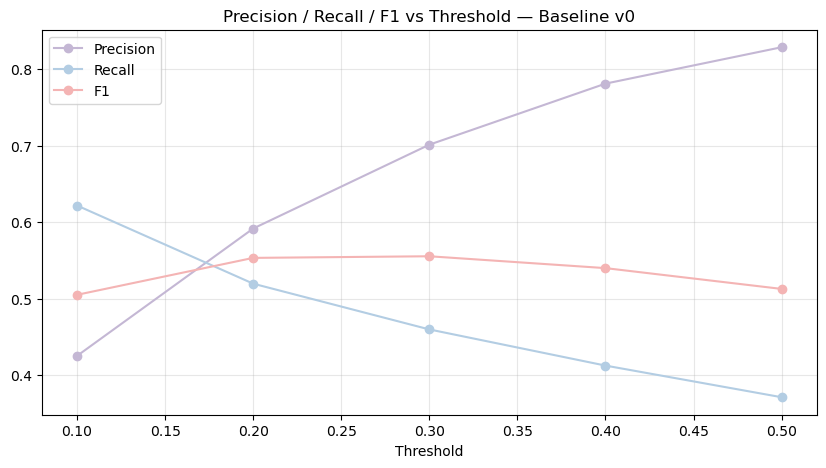

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Threshold visualization
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred = (y_pred_val >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred))
    recalls.append(recall_score(y_val, y_pred))
    f1s.append(f1_score(y_val, y_pred))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, 'o-', label='Precision', color='#c4b7d4')
plt.plot(thresholds, recalls,   'o-', label='Recall',    color='#b3cde3')
plt.plot(thresholds, f1s,       'o-', label='F1',        color='#f4b4b4')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold — Baseline v0')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# Step 8 - Feature Importance — Top 30 Features 

>> Top 30 features by importance:
     1. card1                           importance: 2406
     2. card2                           importance: 1909
     3. tx_day                          importance: 1779
     4. addr1                           importance: 1715
     5. TransactionAmt                  importance: 1528
     6. D15                             importance: 999
     7. tx_dom                          importance: 955
     8. C13                             importance: 939
     9. P_emaildomain                   importance: 902
    10. D1                              importance: 836
    11. D10                             importance: 831
    12. D2                              importance: 773
    13. C1                              importance: 732
    14. card5                           importance: 731
    15. D4                              importance: 664
    16. dist1                           importance: 659
    17. tx_hour                         importance: 648
    18. C

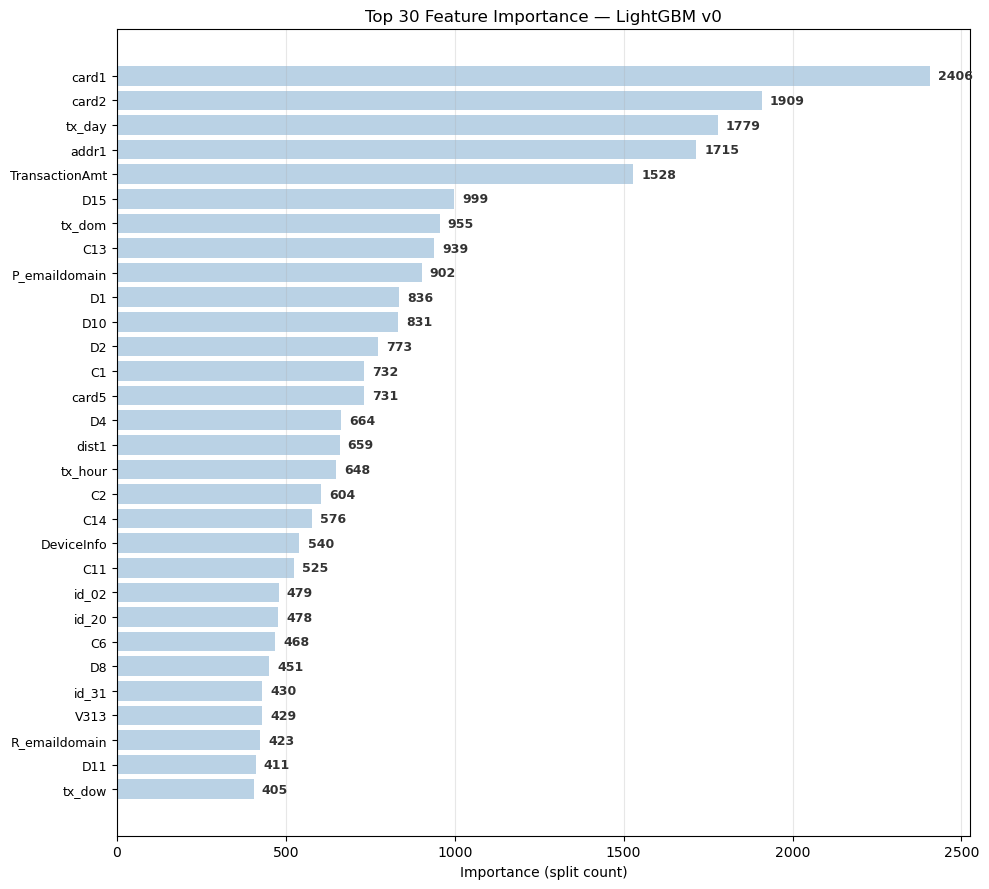

In [10]:
# Feature Importance
from evaluate_v0 import plot_feature_importance
imp_df = plot_feature_importance(model, X_train.columns.tolist(), top_n=30)



# Step 9 — Metrics Tracking

In [11]:
# Save metrics for tracking
import json
baseline_metrics = {
    "version": "baseline_v0",
    "roc_auc": round(metrics["roc_auc"], 6),
    "pr_auc":  round(metrics["pr_auc"],  6),
}
print("Baseline metrics to track:", baseline_metrics)

Baseline metrics to track: {'version': 'baseline_v0', 'roc_auc': np.float64(0.919643), 'pr_auc': np.float64(0.580424)}


# Threshold Analysis — Conclusions

| Threshold | Precision | Recall | F1    |
|-----------|-----------|--------|-------|
| 0.1       | 42.5%     | 62.2%  | 50.5% |
| 0.2       | 59.2%     | 52.0%  | 55.3% |
| 0.3       | 70.1%     | 46.0%  | 55.6% |
| 0.4       | 78.1%     | 41.3%  | 54.0% |
| 0.5       | 83.0%     | 37.0%  | 51.0% |

- Best F1 at threshold **0.2–0.3** (~55.6%)
- Higher threshold → more precise, but misses more fraud
- At threshold=0.5 model catches only 37% of fraud — too conservative for fraud detection